In [1]:
import warnings
warnings.filterwarnings('ignore')

from flonacomldft.utils.io_utils import (
    load_csv_file,
    load_pickle_file,
)

import torch
import numpy as np
import matplotlib.pyplot as plt

from flonacomldft.free_energy_computations import (
    compute_BAR_from_samples, compute_TFP_from_samples
)

## Loading the models - that is only part of them

In [2]:
# To copy data locally
# rsync -av rusty:/mnt/home/amolina/ceph/adaptive-350/adaptive-dft/1-adaptive/results_adaptive_is0_28685740/adaptive_sampling_is0_28685740.pkl adaptive-350/adaptive-dft/1-adaptive/results_adaptive_is0_28685740/
# rsync -av rusty:/mnt/home/amolina/ceph/adaptive-350/adaptive-dft/1-adaptive/results_adaptive_is1_28685741/adaptive_sampling_is1_28685741.pkl adaptive-350/adaptive-dft/1-adaptive/results_adaptive_is1_28685741/
# rsync -av rusty:/mnt/home/amolina/ceph/adaptive-350/adaptive-dft/2-adaptive-mlp/results_adaptive_is0_28706672/adaptive_sampling_is0_28706672.pkl adaptive-350/adaptive-dft/2-adaptive-mlp/results_adaptive_is0_28706672
# rsync -av rusty:/mnt/home/amolina/ceph/adaptive-350/adaptive-dft/2-adaptive-mlp/results_adaptive_is1_28707820/adaptive_sampling_is1_28707820.pkl adaptive-350/adaptive-dft/2-adaptive-mlp/results_adaptive_is1_28707820
# rsync -av rusty:/mnt/home/amolina/ceph/adaptive-350/adaptive-dft/9-free-energy-data/md_flow_data/results_training_flow_is0_2946742/is0_flow_dic_training_2946742.pkl adaptive-350/adaptive-dft/9-free-energy-data/md_flow_data/results_training_flow_is0_2946742/
# rsync -av rusty:/mnt/home/amolina/ceph/adaptive-350/adaptive-dft/9-free-energy-data/md_flow_data/results_training_flow_is1_2946741/is1_flow_dic_training_2946741.pkl adaptive-350/adaptive-dft/9-free-energy-data/md_flow_data/results_training_flow_is1_2946741/

In [3]:
# MARYLOU
project_path = '/Users/marylou/Dropbox/Prof/Experiments/_ceph/ml-dft'
DFT_SIMS_PATH = project_path + '/adaptive-350/adaptive-dft'

# ANA
# DFT_SIMS_PATH = '/mnt/home/amolina/ceph/adaptive-350/adaptive-dft'

#MARYLOU
adaptive_dft_path = ['1-adaptive/results_adaptive_is0_28685740/adaptive_sampling_is0_28685740.pkl',
                    '1-adaptive/results_adaptive_is1_28685741/adaptive_sampling_is1_28685741.pkl']
adaptive_dft_mlp_path = ['2-adaptive-mlp/results_adaptive_is0_28706672/adaptive_sampling_is0_28706672.pkl',
                    '2-adaptive-mlp/results_adaptive_is1_28707820/adaptive_sampling_is1_28707820.pkl']
flow_md_path = ['9-free-energy-data/md_flow_data/results_training_flow_is0_2946742/is0_flow_dic_training_2946742.pkl',
                '9-free-energy-data/md_flow_data/results_training_flow_is1_2946741/is1_flow_dic_training_2946741.pkl']

path_fe = project_path + '/5-FE-comps/0-example'


In [4]:
adaptive_dft_dics = [load_pickle_file('/'+ f, path=DFT_SIMS_PATH) for f in adaptive_dft_path]
adaptive_dft_mlp_dics = [load_pickle_file('/'+ f, path=DFT_SIMS_PATH) for f in adaptive_dft_mlp_path]
md_dics = [load_pickle_file('/'+ f, path=DFT_SIMS_PATH) for f in flow_md_path]

In [5]:
mode_labels = [0, 1]

## Loading the data

In [6]:
dic = {'md_data': '_md', 'flow_mlp_samples' : 'flow_mlp',  
      'flow_dft_samples': 'flow_dft', 'flow_md_samples': 'flow_md', 
      'mcmc_dft_samples': 'mcmc_dft', 'mcmc_mlp_samples': 'mcmc_mlp'}

In [7]:
def load_samples_n_energies(kind, isomer):
    torch_tensor = load_csv_file('is{:d}_{:s}.csv'.format(isomer, dic[kind]),
                  path=project_path + '/data_free_energy')
    return torch_tensor[:, :12], torch_tensor[:, 12]

md_data - 10000 samples
flow_mlp_samples - 10000 samples
flow_dft_samples - 10000 samples
flow_md_samples - 10000 samples
mcmc_dft_samples - 30000 samples
mcmc_mlp_samples - 30000 samples
md_data - 10000 samples
flow_mlp_samples - 10000 samples
flow_dft_samples - 10000 samples
flow_md_samples - 10000 samples
mcmc_dft_samples - 30000 samples
mcmc_mlp_samples - 30000 samples


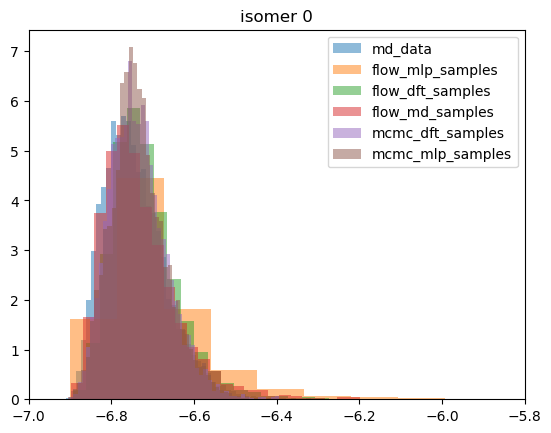

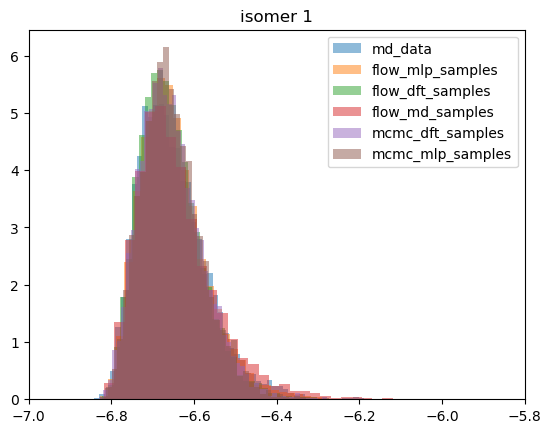

In [8]:
for isomer in mode_labels:
    plt.figure()
    plt.title('isomer {:d}'.format(isomer))
    for kind in dic.keys():
        samples, energies = load_samples_n_energies(kind, isomer)
        print('{:s} - {:d} samples'.format(kind, samples.shape[0]))
        plt.hist(energies, 50, alpha=0.5, label=kind, density=True)
        plt.xlim(-7, -5.8)
    plt.legend()

## TFP computations: 

--> We need to also pass the log prob of the flow that generated the samples

In [12]:
isomer_id = 0

# flowmodels -- @ANA: I am not sure this is all the models? is it?
len(adaptive_dft_dics[isomer]['dict_flows_training'][-1][0]['models'])

11

In [32]:
np.linspace(0, len(models)-1, n_training_slice).astype(int)

array([ 0,  5, 10])

In [10]:
adaptive_dft_dics[isomer].keys()
len(adaptive_dft_mlp_dics[isomer]['dict_mlps_training'])

31

Number of dft computed: 10000
Number of dft computed: 10000


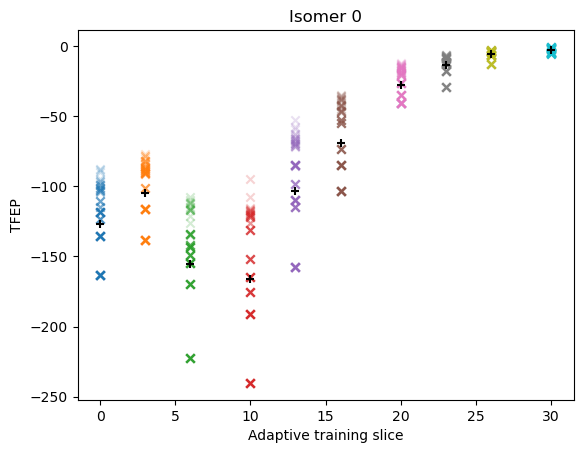

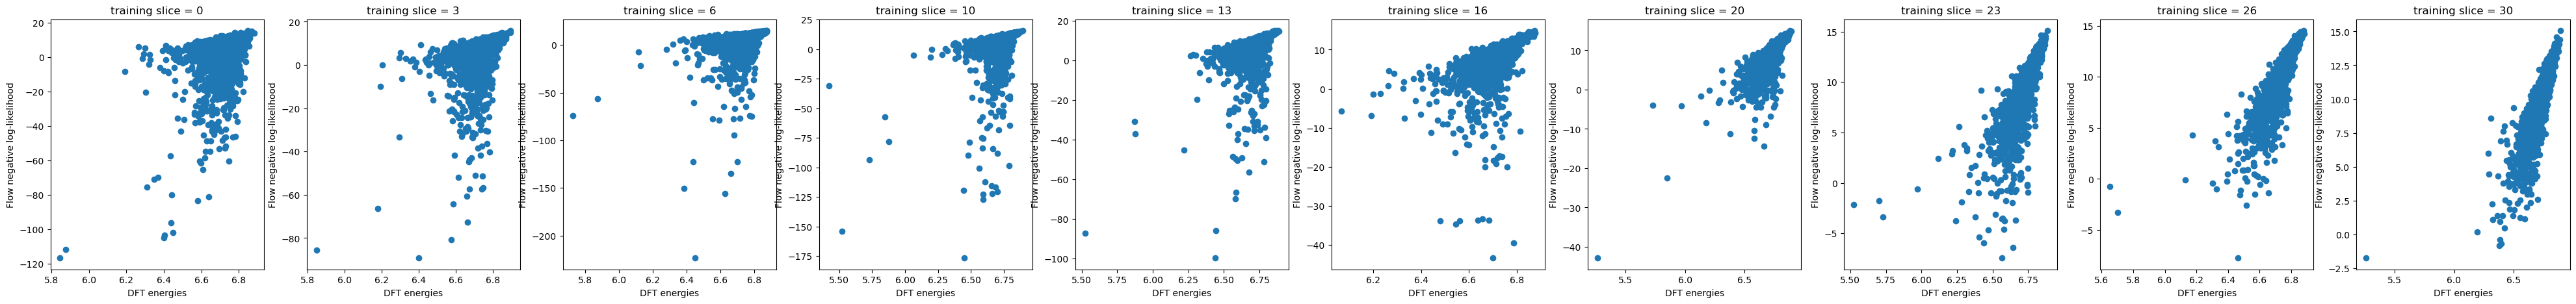

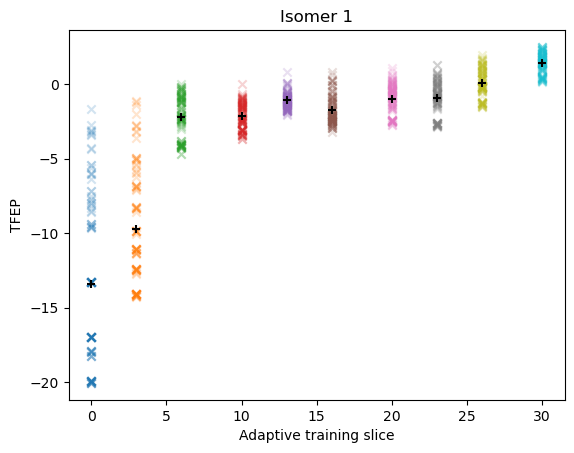

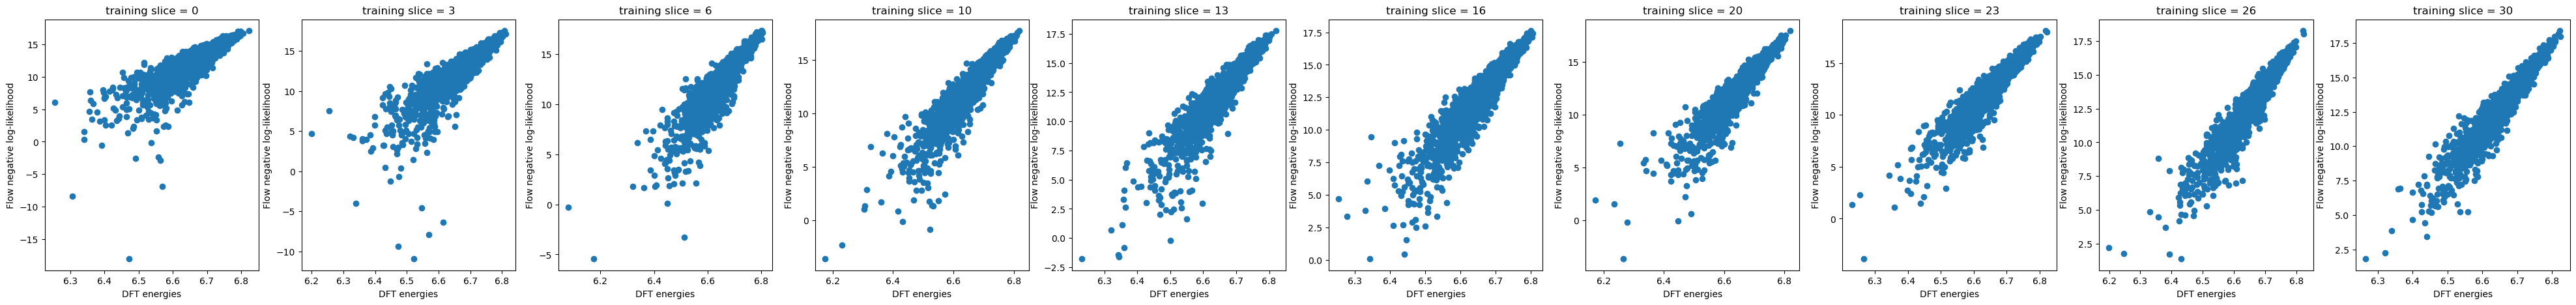

In [63]:
# flow that has been trained by dft

kind = 'flow_dft_samples'
n_train_slice = 10
# train_slice = 10
n_samples = 2000


for isomer_id in mode_labels:
    runs = adaptive_dft_dics[isomer_id]['dict_flows_training']
    train_slices = (np.linspace(0, len(runs)-1, n_train_slice)).astype(int)

    models = [runs[t][0]['models'][-1] for t in train_slices]

    prop_samples, energy_target = load_samples_n_energies(kind, isomer_id)
    print('Number of dft computed:', energy_target.shape[0])

    dic_results_TFPs = {}

    plt.figure()
    ax1 = plt.subplot(111)
    plt.title('Isomer {:d} - {:s}'.format(isomer_id, kind))
    plt.xlabel('Adaptive training slice')
    plt.ylabel('TFEP')

    plt.figure(figsize=(5 * n_train_slice, 5))
    axs = [plt.subplot(1, n_train_slice, i+1) for i in range(n_train_slice)]

    dic_results_TFPs[isomer_id] = {}
    dic_results_TFPs[isomer_id]['means'] = []
    dic_results_TFPs[isomer_id]['stds'] = []

    for t, train_slice in enumerate(train_slices):
        log_ratio_0_TFPs = []
        log_err_0_TFPs = []

        for trial in range(100):
            idx = np.random.choice(energy_target.shape[0], n_samples, replace=False)

            logprob_prop = (- models[t].nll(prop_samples[idx])).detach()
            logprob_target = (-energy_target[idx]).detach()
            logr_TFP_0, log_err_TFP_0 = compute_TFP_from_samples(logprob_prop, logprob_target)
            log_ratio_0_TFPs.append(logr_TFP_0)
            log_err_0_TFPs.append(log_err_TFP_0)

            
        dic_results_TFPs[isomer_id]['means'].append(np.array(log_ratio_0_TFPs).mean())
        dic_results_TFPs[isomer_id]['stds'].append(np.array(log_ratio_0_TFPs).std())

        plt.sca(ax1)
        plt.scatter(np.ones(len(log_ratio_0_TFPs))*train_slice, log_ratio_0_TFPs, marker='x', alpha=0.2)
        plt.scatter(train_slice, np.array(log_ratio_0_TFPs).mean(), c='k', marker='+')
        

        plt.sca(axs[t])
        plt.scatter(logprob_target, logprob_prop)
        plt.xlabel('DFT energies')
        plt.ylabel('Flow negative log-likelihood')
        plt.title('training slice = {:d}'.format(train_slice))
# for isomer in mode_labels:
#     prop_samples, energy_target = load_samples_n_energies(kind, isomer)

#     logprob_prop =  
#     logprob_target = -energy_target

# compute_TFP_from_samples(logprob_prop, logprob_target)

## TODO - TEST COMPARE WITH FLOWS ONLY ON MD 

In [71]:
len(md_dics[isomer_id]['models'])

11

In [18]:
# n_prop = 5

# dic_results_TFPs = {}

# for isomer_id in mode_labels:

#     dic_results_TFPs[isomer_id] = {}
#     dic_results_TFPs[isomer_id]['means'] = []
#     dic_results_TFPs[isomer_id]['stds'] = []

#     plt.figure()
#     plt.title('isomer {:d}'.format(isomer_id))
#     for r,run in enumerate(adaptives_dic[isomer_id]['dict_flows_training']):
#         flow = run[0]['models'][-1]
#         log_ratio_0_TFPs = []
#         log_err_0_TFPs = []

#         for trial in range(10):
#             logr_TFP_0, log_err_TFP_0 = compute_TFP(n_prop, target_log_probs[isomer_id], flow)
#             log_ratio_0_TFPs.append(logr_TFP_0)
#             log_err_0_TFPs.append(log_err_TFP_0)
        
#         dic_results_TFPs[isomer_id][r] = (log_ratio_0_TFPs, log_err_0_TFPs)
        
#         plt.scatter(np.ones(len(log_ratio_0_TFPs))*r, log_ratio_0_TFPs, marker='x', alpha=0.2)
#         plt.scatter(r, np.array(log_ratio_0_TFPs).mean(), c='k', marker='+')

#         dic_results_TFPs[isomer_id]['means'].append(np.array(log_ratio_0_TFPs).mean())
#         dic_results_TFPs[isomer_id]['stds'].append(np.array(log_ratio_0_TFPs).std())
    
#     plt.errorbar(np.arange(len(dic_results_TFPs[isomer_id]['means'])), dic_results_TFPs[isomer_id]['means'], yerr=dic_results_TFPs[isomer_id]['stds'], fmt='o')
       

#     plt.xlabel('adaptive mcmc retraining stage')
#     plt.ylabel('log ratio by Targeted Free energy Perturbation (TFP)')

#     # print('logr_TFP {:.3e} +/- {:.3e}'.format(np.array(log_ratio_0_TFPs).mean(), np.array(log_ratio_0_TFPs).std()))

: 

: 

: 